In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

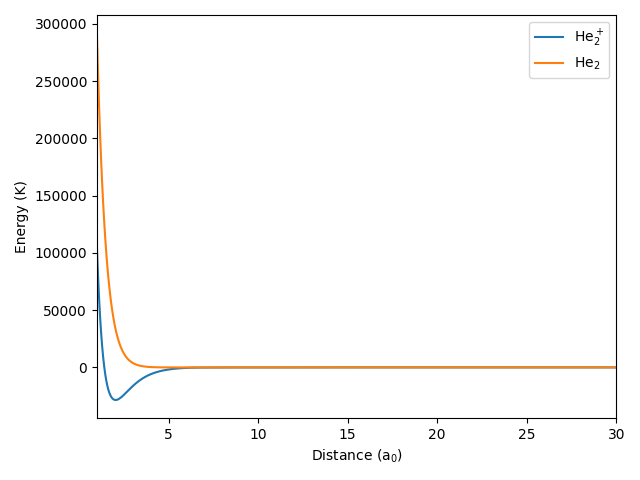

In [3]:
from tbr.potentials import He2_V, He2_dV, He2plus_V, He2plus_dV
from tbr.constants import K2HAR

v_he2 = He2_V()
dv_he2 = He2_dV()

v_he2p = He2plus_V()
dv_he2p = He2plus_dV()

# He + He + He(+)
v_funcs = (v_he2, v_he2p, v_he2p)
dv_funcs = (dv_he2, dv_he2p, dv_he2p)

x = np.linspace(1, 30, 500)
y_he2p = np.array([v_he2p(i) for i in x])/K2HAR

# Plot potentials
plt.figure()
plt.plot(x, y_he2p, label = f'He$_2^+$')
plt.plot(x, v_he2(x)/K2HAR, label = f'He$_2$')
plt.xlim(1, 30)
# plt.ylim(min(y_he2p), 1e-2) # He2(+)
# plt.ylim(min(v_he2(x))/K2HAR, 1e-2) # He2
plt.xlabel(r'Distance (a$_0$)')
plt.ylabel('Energy (K)')
plt.tight_layout()
plt.legend()
plt.show()

In [4]:
# Trajectory parameters
# Type A + A + B
masses = (2*14.007, 2*14.007, 4.0026) # He, He, He+
m1, m2, m3 = masses
E0 = 1 # Kelvin
R0 = 500.0
dR0 = 0.1*R0
b0 = 0

v_funcs = (v_he2, v_he2p, v_he2p)
dv_funcs = (dv_he2, dv_he2p, dv_he2p)

In [5]:
# Simulate one trajectory
from tbr.simulator import run_trajectory_worker
import time

# seed = int(np.random.random()*8923)
seed = 23054
print(f'Running trajectory with seed {seed}...')
task_data = m1, m2, m3, E0, b0, R0, v_funcs, dv_funcs, seed
t0 = time.time()
solution = run_trajectory_worker(task_data=task_data)
tf = time.time()
print(f'Trajectory run in {tf-t0} s')

Running trajectory with seed 23054...
Energy drift 1.6332561182107015e-10 Hartree
Trajectory run in 21.707018613815308 s


Result (n12, n23, n31, nd, nc): [0 0 1 0 0]


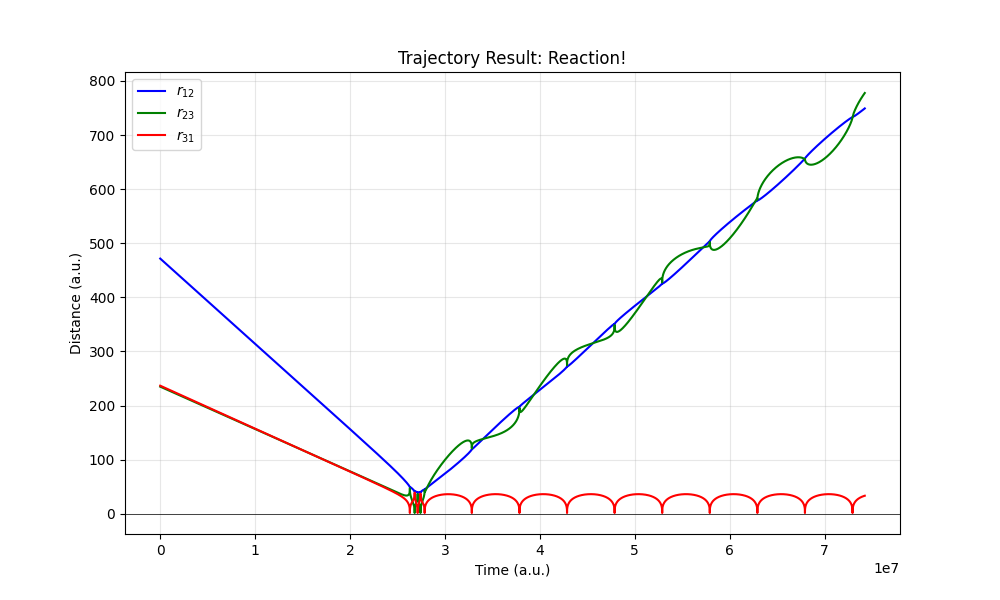

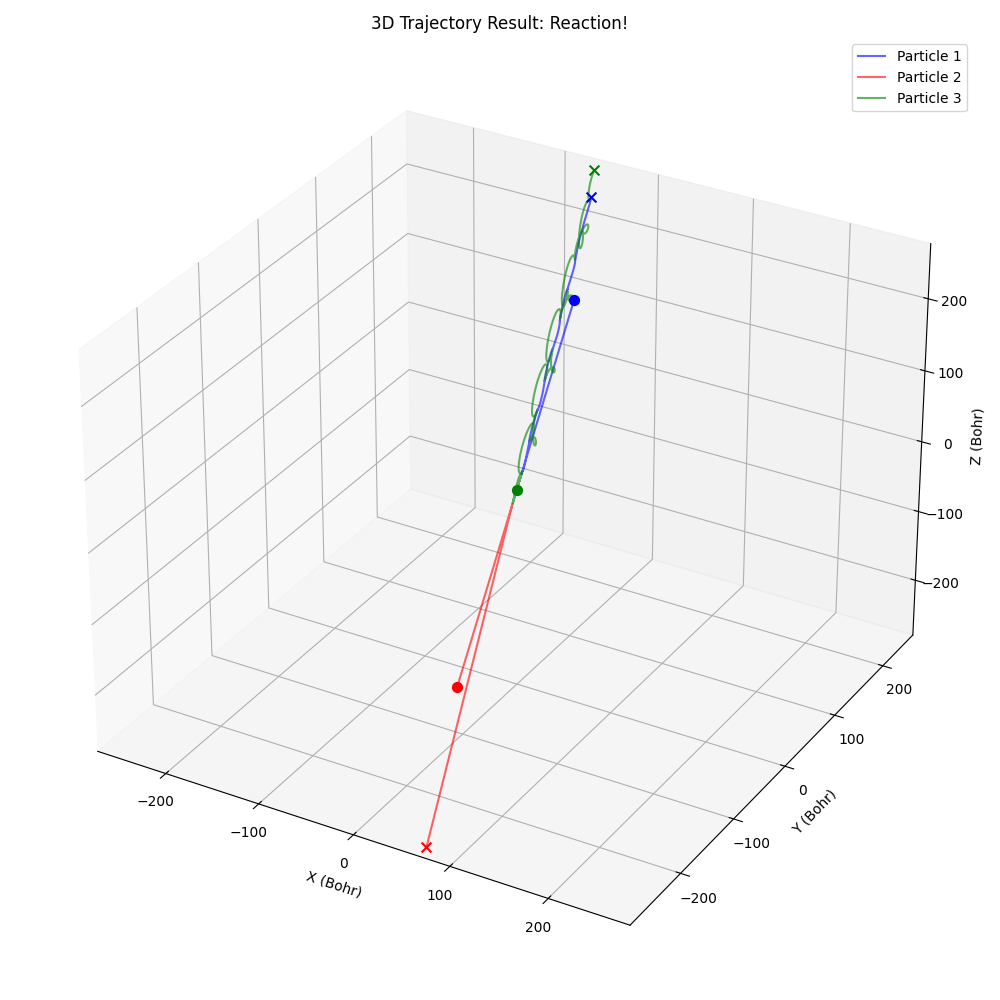

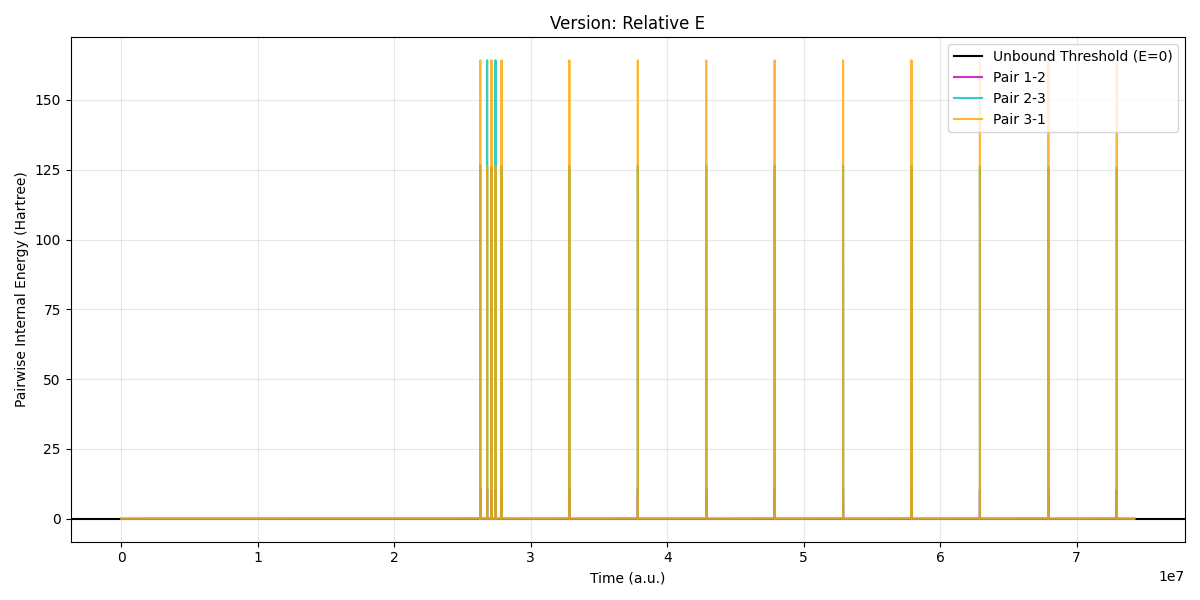

In [6]:
# Plot trajectory
from tbr.simulator import get_distances_from_solution
from tbr.plotters import plot_distances, plot_3d_motion, plot_relative_e

# Observables
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T
print(f'Result (n12, n23, n31, nd, nc): {n_res}')
plot_distances(solution, masses)
# plot_3d_motion(data_block, m1, m2, m3, seed)
plot_3d_motion(solution, masses)
plot_relative_e(solution, masses, v_funcs)
plt.show()

Running trajectory with seed 25141...
Energy drift 3.8839302003631235e-14 Hartree
Trajectory run in 0.2912125587463379 s
Running trajectory with seed 26742...
Energy drift 2.9260773556912076e-11 Hartree
Trajectory run in 1.276700496673584 s
Running trajectory with seed 31147...
Energy drift 2.3594486875210116e-14 Hartree
Trajectory run in 0.3396265506744385 s
Running trajectory with seed 29732...
Energy drift 2.0858187051620865e-11 Hartree
Trajectory run in 0.950890302658081 s
Running trajectory with seed 27260...
Energy drift 2.6947915300861835e-14 Hartree
Trajectory run in 0.2542421817779541 s
Running trajectory with seed 29352...
Energy drift 1.471003939486446e-13 Hartree
Trajectory run in 0.2744417190551758 s
Running trajectory with seed 29706...
Energy drift 1.1426887043550438e-11 Hartree
Trajectory run in 0.6725466251373291 s
Running trajectory with seed 23173...
Energy drift 1.1349475896125502e-11 Hartree
Trajectory run in 0.5038654804229736 s
Running trajectory with seed 26103.

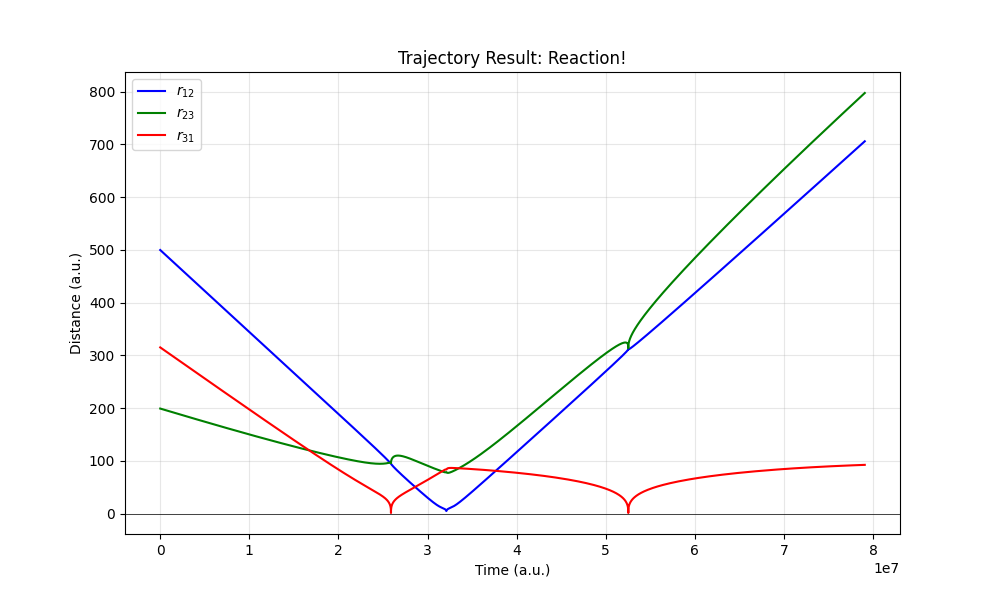

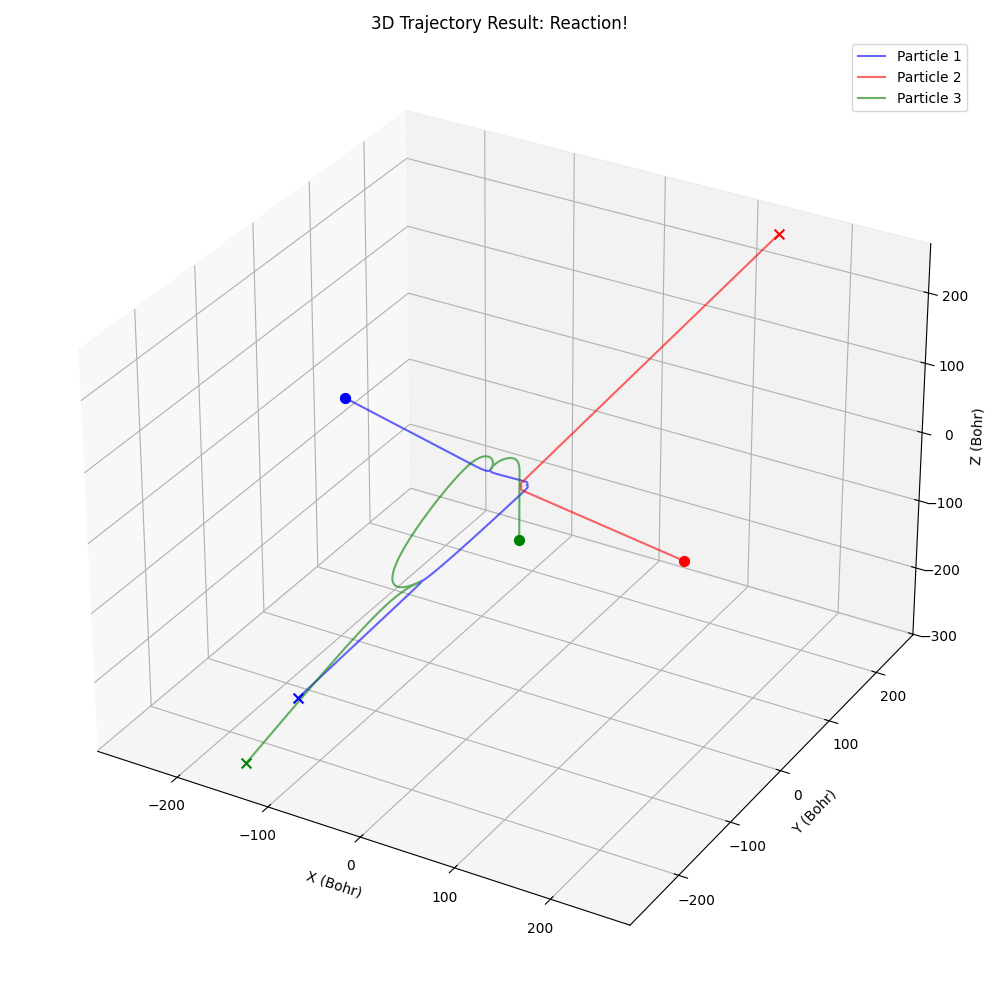

In [7]:
# Simulate until a reaction is found 

def run_t():
    seed = int(np.random.random()*8923) + 23013
    print(f'Running trajectory with seed {seed}...')
    task_data = m1, m2, m3, E0, b0, R0,  v_funcs, dv_funcs, seed
    t0 = time.time()
    solution = run_trajectory_worker(task_data=task_data)
    tf = time.time()
    print(f'Trajectory run in {tf-t0} s')
    
    return solution

solution = run_t()
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']
n_t = 0
while (n_res[3] == 1) & (n_t < 100): # search for non-dissociative trajectories 
    solution = run_t()
    n_res = solution['n_res']
    rho_vec = solution['positions_rho']
    p_vec = solution['momenta_p']
    n_t+=1


if solution['success'] == True:
    r12, r23, r31 = get_distances_from_solution(
                np.vstack([rho_vec, p_vec]), m1, m2
            )

    data_block = np.vstack([
                solution['times'], 
                r12, r23, r31,
                solution['positions_rho'], 
                solution['momenta_p']
            ]).T
    print(f'Result (n12, n23, n31, nd, nc): {n_res}')
    plot_distances(solution, masses)
    plot_3d_motion(solution, masses)
    # plot_relative_e(solution, masses, v_funcs)

In [57]:
from tbr.analysis import opacity, cross_section, rate
from tbr.constants import U2ME

in_file = 'results/heplus_short.txt'

masses = (4.0026, 4.0026, 4.0026) # N2, N2+, He
reactants = ['He', 'He', 'He+'] # or ['A', 'A', 'B']
m1, m2, m3 = masses
mu0 = np.sqrt(m1*m2*m3/(m1+m2+m3))
m12 = m1*m2/(m1+m2)
tolerance_numerator = 10
window_size = 3
tolerances = {'AA': 10, 'AB': 50}
windows = {'AA': 3, 'AB': 8}

opac = opacity(in_file, reactants)
sigma = cross_section(opac, reactants, tolerances=tolerances, windows=windows)
k3 = rate(opac, mu0, reactants, windows=windows, tolerances=tolerances)

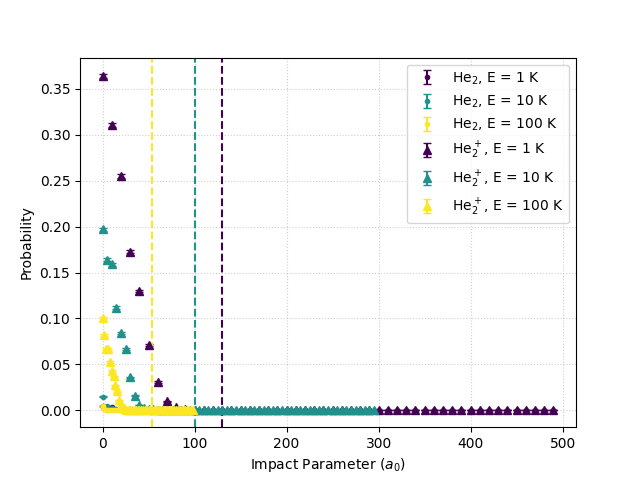

In [59]:
# Visualize opacity
from tbr.plotters import plot_opac

e_list = [1, 10, 100]
bmax_AA = k3[k3['e'].isin(e_list)]['bmax_AA'].reset_index(drop=True)
bmax_AB = k3[k3['e'].isin(e_list)]['bmax_AB'].reset_index(drop=True)
colors = plt.cm.viridis(np.linspace(0,1,len(e_list)))

plt.figure()
plot_opac(opac, [1, 10, 100], suffix='AA', fmt = '.', label = r'He$_2$')
plot_opac(opac, [1, 10, 100], suffix='AB', fmt = '^', label = r'He$_2^+$')

# Vertical lines for bmax_AB
for e, bmax in bmax_AB.items():
    plt.axvline(bmax, 0, 1, linestyle='--', color = colors[e])

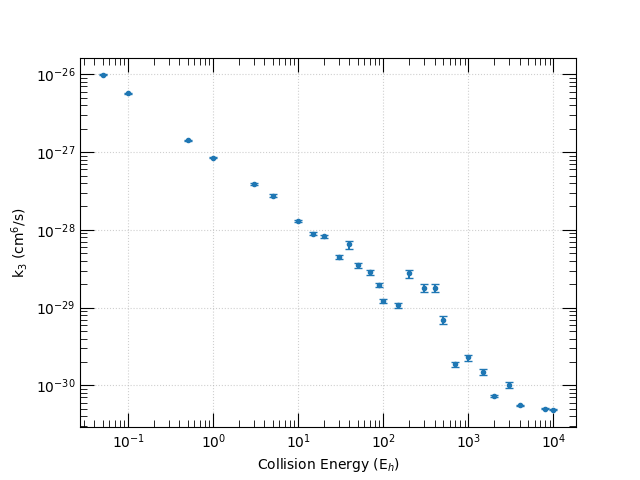

In [60]:
plt.figure()
plt.errorbar(k3['e'], k3['k_AB'], k3['k_AB_err'], fmt = '.', capsize=3, label = r'He + He + He$^+$ $\rightarrow$He$_2^+$ + He')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'Collision Energy (E$_h$)')
plt.ylabel(r'k$_3$ (cm$^6$/s)')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(direction='in',which='minor',length=5,
                bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=10,
                bottom=True, top=True, left=True, right=True)

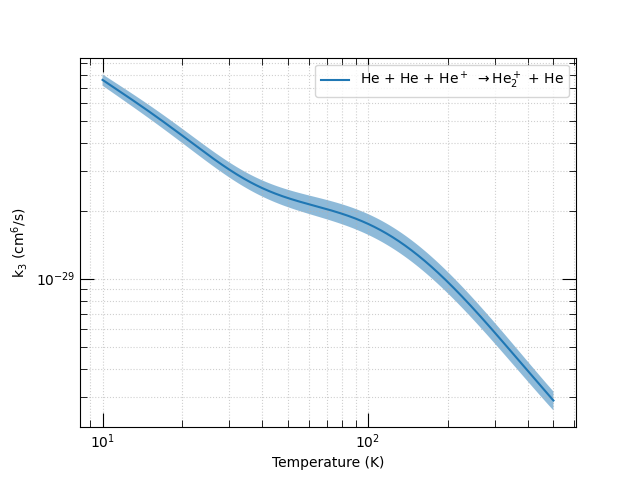

In [61]:
from tbr.analysis import thermal_rate

temps = np.linspace(10, 500, 1000)
k3_therm = thermal_rate(k3, temps, process = 'AB')
plt.figure()
plt.plot(k3_therm['T_K'], k3_therm['k_thermal_AB'], 
             label = r'He + He + He$^+$ $\rightarrow$He$_2^+$ + He')
plt.fill_between(k3_therm['T_K'], k3_therm['k_thermal_AB'] - k3_therm['k_thermal_AB_err'],
                 k3_therm['k_thermal_AB'] + k3_therm['k_thermal_AB_err'], alpha = 0.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'Temperature (K)')
plt.ylabel(r'k$_3$ (cm$^6$/s)')
plt.legend()
plt.grid(True, linestyle=':', which = 'both', alpha=0.6)
plt.tick_params(direction='in',which='minor',length=5,
                bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=10,
                bottom=True, top=True, left=True, right=True)